In [ ]:
!pip install scanpy==1.9.3 anndata==0.8.0
!pip install scikit-learn
!pip install matplotlib
!pip install pandas
!pip install numpy
!pip install harmonypy
!pip install scvi-tools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.1/96.1 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.6/87.6 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 92.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 662.1/662.1 kB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 62.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 104.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.3/174.3 kB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 119.0 MB/s eta 0:00:00
   ━━━

In [ ]:
import scanpy as sc
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
import seaborn as sns

In [ ]:
# mount drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Dataset

In [ ]:
# import anndata as ad

data_path = "/content/drive/MyDrive/GP_datasets/Colon/colon_merged.h5ad"


In [ ]:
# read adata
adata = sc.read_h5ad(data_path)

In [ ]:
print(adata)

AnnData object with n_obs × n_vars = 32636 × 12502
    obs: 'cell_type', 'species', 'assay'
    uns: 'cell_type_colors', 'neighbors', 'species_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    obsp: 'connectivities', 'distances'


## Normalization

In [ ]:
# make sure there is a counts layer for scvi
adata.layers["counts"] = adata.X

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [ ]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.raw = adata  # keep full dimension safe
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=4000,
    flavor="seurat_v3",
    layer="counts",
    subset=True,
    batch_key="species",  #
)

In [ ]:
import scvi
import scanpy as sc

# Make sure categorical columns are string type
# adata.obs["donor_id"] = adata.obs["donor_id"].astype(str)

# Prepare AnnData for SCVI
scvi.model.SCVI.setup_anndata(
    adata,
    layer = "counts",
    batch_key="species",
)

In [ ]:
vae = scvi.model.SCVI(adata, n_layers=2, n_latent=30, gene_likelihood="nb")
vae.train(max_epochs=100, early_stopping=True)

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespe

Training:   0%|          | 0/100 [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=100` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=100` reached.


In [ ]:
adata.obsm["X_scVI"] = vae.get_latent_representation()

In [ ]:
# save embeddings to drive
adata.write("/content/drive/MyDrive/GP_datasets/Colon_combined_Human+Monkey_embeddings_scVI.h5ad")

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import silhouette_score
from harmonypy import compute_lisi

def compute_silhouette_and_lisi_avg(adata, label_keys, embed_key, k_lisi=30):

    X = adata.obsm[embed_key]
    metadata = adata.obs[label_keys]

    # Silhouette scores
    sil_scores = {}
    for key in label_keys:
        labels = adata.obs[key].astype(str).values

        if len(np.unique(labels)) > 1:
            sil_scores[key] = silhouette_score(X, labels)
        else:
            sil_scores[key] = np.nan

    # LISI scores
    lisi_scores = compute_lisi(
        X,
        metadata,
        label_colnames=label_keys,
        perplexity=k_lisi
    )

    lisi_df = pd.DataFrame(
        lisi_scores,
        columns=label_keys,
        index=adata.obs_names
    )

    scores = {
        "silhouette": sil_scores,
        "lisi": lisi_df.mean().to_dict()
    }

    return scores

In [ ]:
label_keys = ["cell_type", "species"]
# Compute scores
scores = compute_silhouette_and_lisi_avg(adata, label_keys, embed_key="X_scVI", k_lisi=30)
print("Silhouette Scores:", scores["silhouette"])
print("LISI Scores:", scores["lisi"])


Silhouette Scores: {'cell_type': np.float32(0.12720415), 'species': np.float32(0.009185477)}
LISI Scores: {'cell_type': 1.0193813064982156, 'species': 1.0744971621715709}


In [ ]:
# "Label Transfer"

train_out = "/content/drive/MyDrive/GP_datasets/Colon_combined_Human+Monkey_embeddings_scVI.h5ad"

adata = sc.read(train_out)

adata

AnnData object with n_obs × n_vars = 32636 × 4000
    obs: 'cell_type', 'species', 'assay', '_scvi_batch', '_scvi_labels'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'cell_type_colors', 'hvg', 'log1p', 'neighbors', 'species_colors', 'umap'
    obsm: 'X_pca', 'X_scVI', 'X_umap'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

# Human --> Monkey

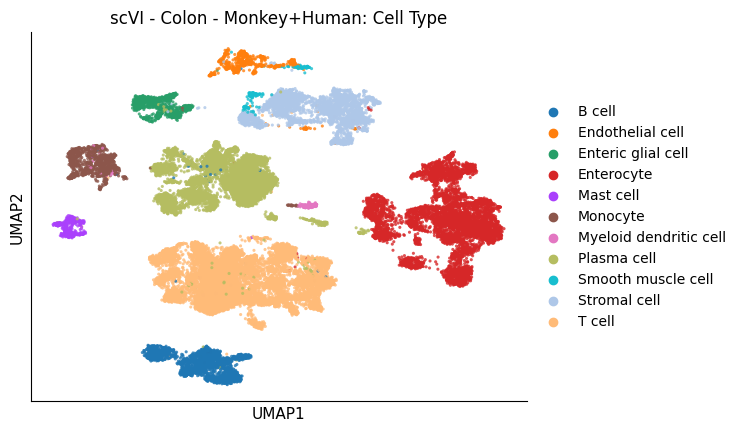

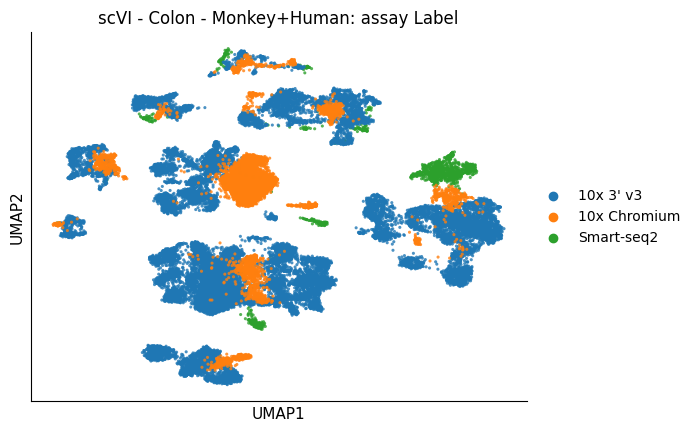

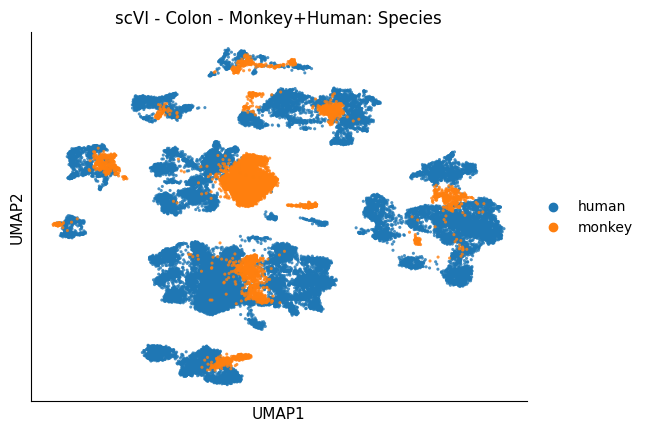

=== Logistic Regression ===
Accuracy: 0.8897517892492767
                        precision    recall  f1-score   support

                B cell       0.82      0.96      0.88       326
      Endothelial cell       0.97      0.72      0.83       275
    Enteric glial cell       0.82      1.00      0.90        70
            Enterocyte       0.81      1.00      0.89       405
             Mast cell       1.00      1.00      1.00        49
              Monocyte       0.97      0.78      0.86       334
Myeloid dendritic cell       0.62      0.93      0.74       137
           Plasma cell       1.00      0.89      0.94      3698
    Smooth muscle cell       0.00      0.00      0.00       126
          Stromal cell       0.75      1.00      0.86       407
                T cell       0.76      1.00      0.87       740

              accuracy                           0.89      6567
             macro avg       0.77      0.84      0.80      6567
          weighted avg       0.90      0.89  

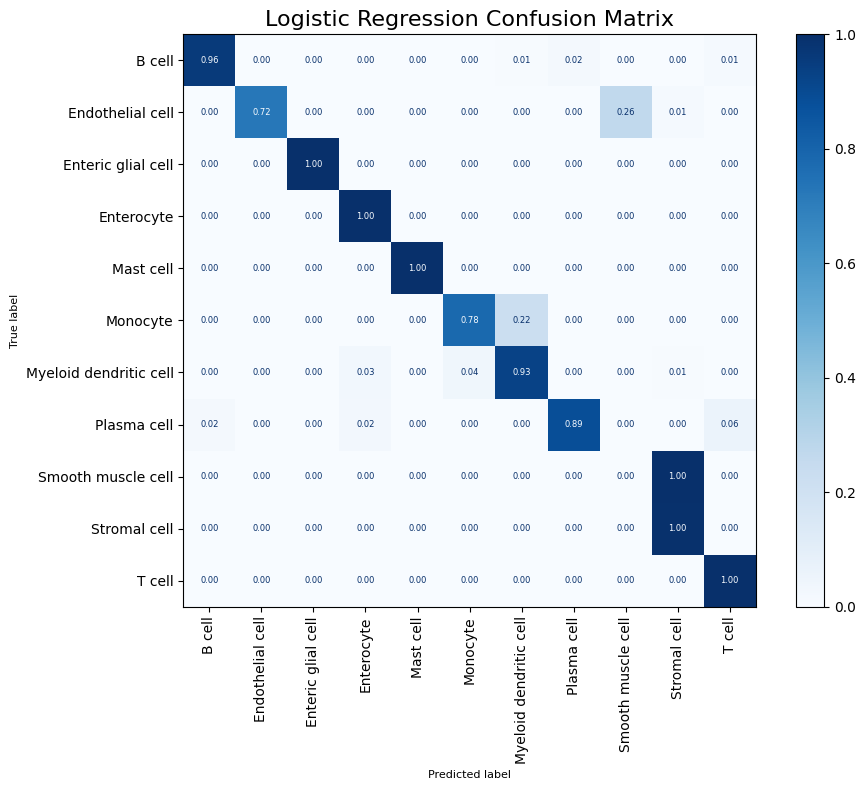


=== k-NN ===
Accuracy: 0.8123953098827471
                        precision    recall  f1-score   support

                B cell       0.80      0.95      0.87       326
      Endothelial cell       0.91      0.74      0.82       275
    Enteric glial cell       0.86      1.00      0.93        70
            Enterocyte       0.64      1.00      0.78       405
             Mast cell       0.84      1.00      0.92        49
              Monocyte       0.72      0.95      0.82       334
Myeloid dendritic cell       0.38      0.07      0.11       137
           Plasma cell       1.00      0.77      0.87      3698
    Smooth muscle cell       0.00      0.00      0.00       126
          Stromal cell       0.69      1.00      0.82       407
                T cell       0.60      0.99      0.75       740

              accuracy                           0.81      6567
             macro avg       0.68      0.77      0.70      6567
          weighted avg       0.85      0.81      0.81      

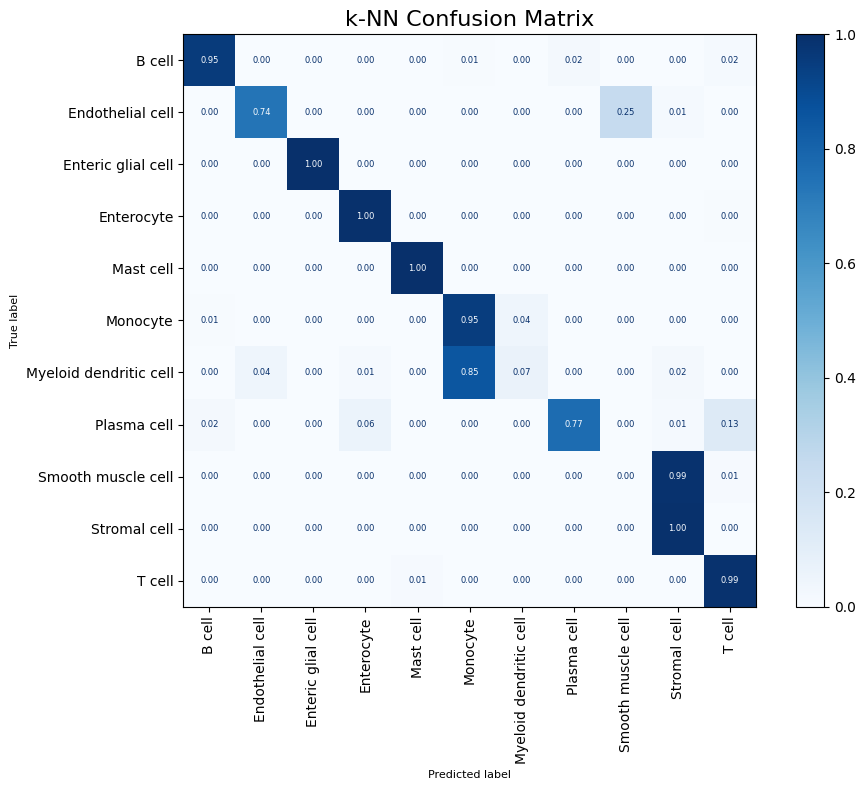

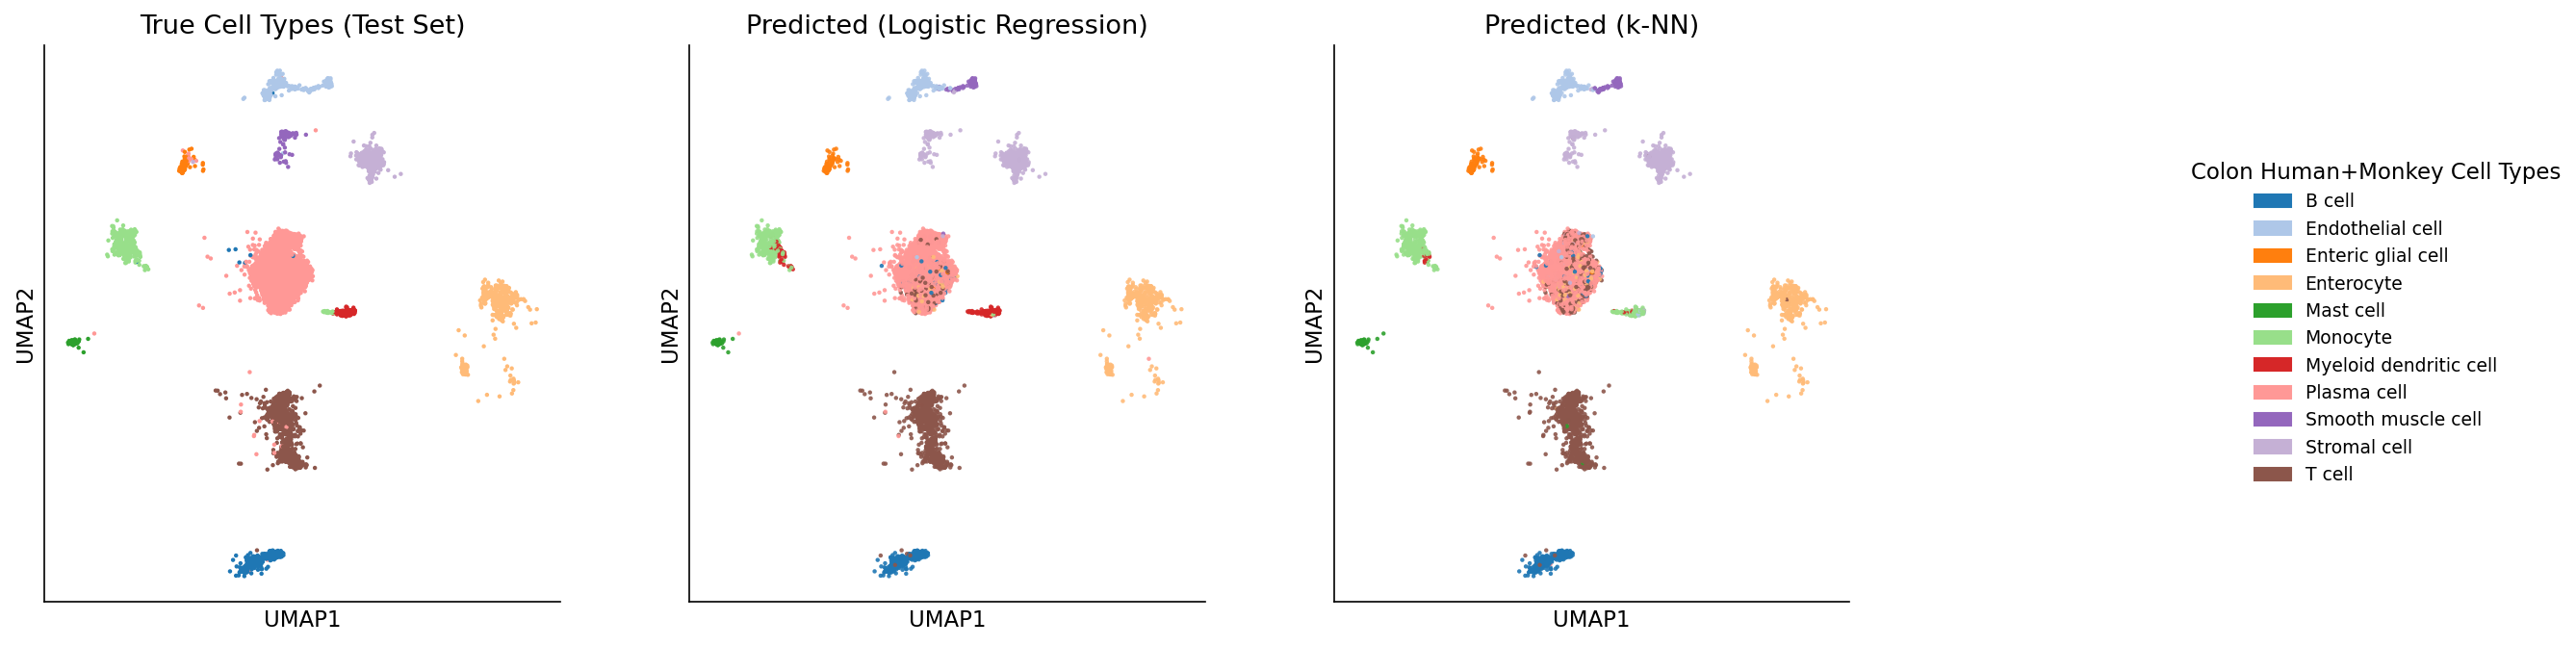

In [ ]:

## Visualization

from sklearn.metrics import ConfusionMatrixDisplay


sc.pp.neighbors(adata, use_rep="X_scVI")
sc.tl.umap(adata)

ax = sc.pl.umap(
    adata,
    color='cell_type',
    size=20,
    alpha=0.8,
    frameon=True,
    show=False,
    title="scVI - Colon - Monkey+Human: Cell Type"
)

ax.set_facecolor("white")
ax.set_xlabel("UMAP1", fontsize=11)
ax.set_ylabel("UMAP2", fontsize=11)

# Make axis lines visible
ax.spines[['left', 'bottom']].set_visible(True)

# Remove top/right box lines (clean style)
ax.spines[['top', 'right']].set_visible(False)

# Make axes black
ax.spines[['left', 'bottom']].set_color("black")

plt.show()

ax = sc.pl.umap(
    adata,
    color='assay',
    size=20,
    alpha=0.8,
    frameon=True,
    show=False,
    title="scVI - Colon - Monkey+Human: assay Label"
)

ax.set_facecolor("white")
ax.set_xlabel("UMAP1", fontsize=11)
ax.set_ylabel("UMAP2", fontsize=11)

# Make axis lines visible
ax.spines[['left', 'bottom']].set_visible(True)

# Remove top/right box lines (clean style)
ax.spines[['top', 'right']].set_visible(False)

# Make axes black
ax.spines[['left', 'bottom']].set_color("black")

plt.show()

ax = sc.pl.umap(
    adata,
    color='species',
    size=20,
    alpha=0.8,
    frameon=True,
    show=False,
    title="scVI - Colon - Monkey+Human: Species"
)

ax.set_facecolor("white")
ax.set_xlabel("UMAP1", fontsize=11)
ax.set_ylabel("UMAP2", fontsize=11)

# Make axis lines visible
ax.spines[['left', 'bottom']].set_visible(True)

# Remove top/right box lines (clean style)
ax.spines[['top', 'right']].set_visible(False)

# Make axes black
ax.spines[['left', 'bottom']].set_color("black")

plt.show()

## Build a cell-type classifier using Geneformer embeddings  3 batches for train and 1 for test

train_data = adata[adata.obs["species"] != "monkey"]
test_data  = adata[adata.obs["species"] == "monkey"]

X_train = train_data.obsm["X_scVI"]
X_test  = test_data.obsm["X_scVI"]

y_train = train_data.obs["cell_type"]
y_test  = test_data.obs["cell_type"]


# logistic regression
clf = LogisticRegression(max_iter=300, solver='lbfgs')

clf.fit(X_train, y_train)
y_pred_lr = clf.predict(X_test)

# KNN
knn = KNeighborsClassifier(
    n_neighbors=15,
    weights="distance",
    metric="cosine"
)

knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

def plot_cm(y_true, y_pred, title):
    # Reset to default style to ensure consistency
    plt.rcdefaults()
    plt.rcParams.update({
        'figure.facecolor': 'white',
        'axes.facecolor': 'white',
        'font.family': 'sans-serif',
        'font.size': 10,
    })

    labels = np.unique(y_true)
    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize="true")

    fig, ax = plt.subplots(figsize=(10, 8), dpi=100)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(
        ax=ax,
        cmap="Blues",
        xticks_rotation=90,
        values_format=".2f",
        colorbar=True
    )
    ax.grid(False)

    for text in ax.texts:
        text.set_fontsize(6)

    plt.title(title, fontsize=16)
    plt.xlabel("Predicted label", fontsize=8)
    plt.ylabel("True label", fontsize=8)

    plt.tight_layout()
    plt.show()

print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
plot_cm(y_test, y_pred_lr, "Logistic Regression Confusion Matrix")


print("\n=== k-NN ===")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))
plot_cm(y_test, y_pred_knn, "k-NN Confusion Matrix")

# Attach predictions to test dataset
test_data.obs["y_pred_lr"] = y_pred_lr
test_data.obs["y_pred_knn"] = y_pred_knn

# Fill missing values
test_data.obs["y_pred_lr"] = test_data.obs["y_pred_lr"].astype(str).fillna("Unassigned")
test_data.obs["y_pred_knn"] = test_data.obs["y_pred_knn"].astype(str).fillna("Unassigned")

# Convert to categorical
test_data.obs["cell_type"] = test_data.obs["cell_type"].astype("category") # Changed from celltype to cell_type
test_data.obs["y_pred_lr"] = test_data.obs["y_pred_lr"].astype("category")
test_data.obs["y_pred_knn"] = test_data.obs["y_pred_knn"].astype("category")

# Unified label set
all_labels = sorted(
    set(test_data.obs["cell_type"].cat.categories)
    | set(test_data.obs["y_pred_lr"].cat.categories)
    | set(test_data.obs["y_pred_knn"].cat.categories)
)

# Force same category order
test_data.obs["cell_type"] = test_data.obs["cell_type"].cat.set_categories(all_labels)
test_data.obs["y_pred_lr"] = test_data.obs["y_pred_lr"].cat.set_categories(all_labels)
test_data.obs["y_pred_knn"] = test_data.obs["y_pred_knn"].cat.set_categories(all_labels)

# Color map
palette = sc.pl.palettes.vega_20
color_map = {label: palette[i % len(palette)] for i, label in enumerate(all_labels)}
color_map["Unassigned"] = "lightgray"

# Plot
fig, axes = plt.subplots(1, 3, figsize=(20, 5), dpi=150)

common_kwargs = dict(
    show=False,
    size=18,
    frameon=True,
    palette=color_map
)

# True labels
sc.pl.umap(test_data, color="cell_type", ax=axes[0], **common_kwargs)
axes[0].set_title("True Cell Types (Test Set)", fontsize=13)

# Logistic Regression predictions
sc.pl.umap(test_data, color="y_pred_lr", ax=axes[1], alpha=0.9, **common_kwargs)
axes[1].set_title("Predicted (Logistic Regression)", fontsize=13)

# KNN predictions
sc.pl.umap(test_data, color="y_pred_knn", ax=axes[2], alpha=0.9, **common_kwargs)
axes[2].set_title("Predicted (k-NN)", fontsize=13)

# Remove auto legends
for ax in axes:
    # Remove auto legend
    if ax.legend_:
        ax.legend_.remove()

    # Force white background
    ax.set_facecolor("white")

    # Axis labels
    ax.set_xlabel("UMAP1", fontsize=11)
    ax.set_ylabel("UMAP2", fontsize=11)

    # Make axis lines visible
    ax.spines[['left', 'bottom']].set_visible(True)

    # Remove top/right box lines (clean style)
    ax.spines[['top', 'right']].set_visible(False)

    # Make axes black
    ax.spines[['left', 'bottom']].set_color("black")

    # Ticks
    ax.tick_params(
        axis='both',
        which='major',
        labelsize=9,
        colors='black'
    )
# Single clean legend
from matplotlib.patches import Patch
handles = [Patch(color=color_map[label], label=label) for label in all_labels]
fig.legend(
    handles=handles,
    title="Colon Human+Monkey Cell Types",
    loc="center right",
    frameon=False,
    fontsize=9,
    title_fontsize=11,
    ncol=1
)
plt.subplots_adjust(right=0.75, wspace=0.25)
# plt.tight_layout()
plt.show()

## Monkey --> Human

=== Logistic Regression ===
Accuracy: 0.8513176569872262
                        precision    recall  f1-score   support

                B cell       0.93      0.99      0.96      2069
      Endothelial cell       0.70      0.91      0.79       348
    Enteric glial cell       0.99      0.98      0.99       848
            Enterocyte       1.00      0.91      0.95      5657
             Mast cell       0.98      0.96      0.97       393
              Monocyte       0.78      0.98      0.87       748
Myeloid dendritic cell       0.20      0.03      0.04        40
           Plasma cell       0.60      0.98      0.74      3308
    Smooth muscle cell       0.00      0.01      0.00        82
          Stromal cell       0.98      0.56      0.71      2597
                T cell       1.00      0.81      0.89      9979

              accuracy                           0.85     26069
             macro avg       0.74      0.74      0.72     26069
          weighted avg       0.93      0.85  

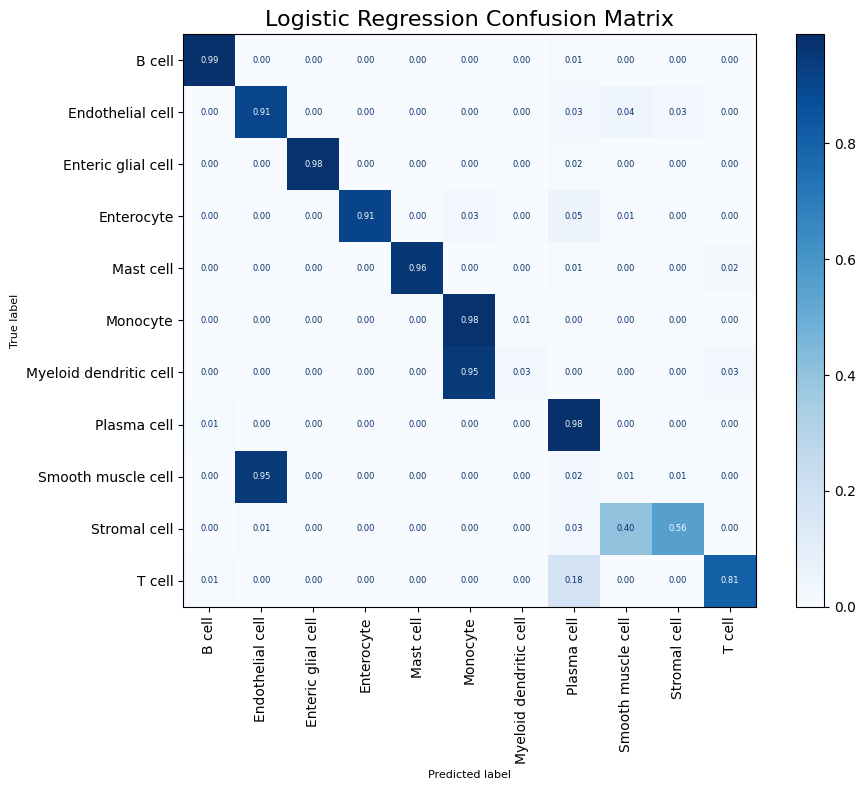


=== k-NN ===
Accuracy: 0.879780582300817
                        precision    recall  f1-score   support

                B cell       0.99      0.96      0.98      2069
      Endothelial cell       0.72      0.91      0.80       348
    Enteric glial cell       0.98      1.00      0.99       848
            Enterocyte       1.00      0.96      0.98      5657
             Mast cell       0.95      0.98      0.97       393
              Monocyte       0.91      0.99      0.95       748
Myeloid dendritic cell       0.25      0.03      0.05        40
           Plasma cell       0.66      0.99      0.79      3308
    Smooth muscle cell       0.00      0.02      0.00        82
          Stromal cell       0.97      0.56      0.71      2597
                T cell       1.00      0.85      0.92      9979

              accuracy                           0.88     26069
             macro avg       0.77      0.75      0.74     26069
          weighted avg       0.94      0.88      0.90     26

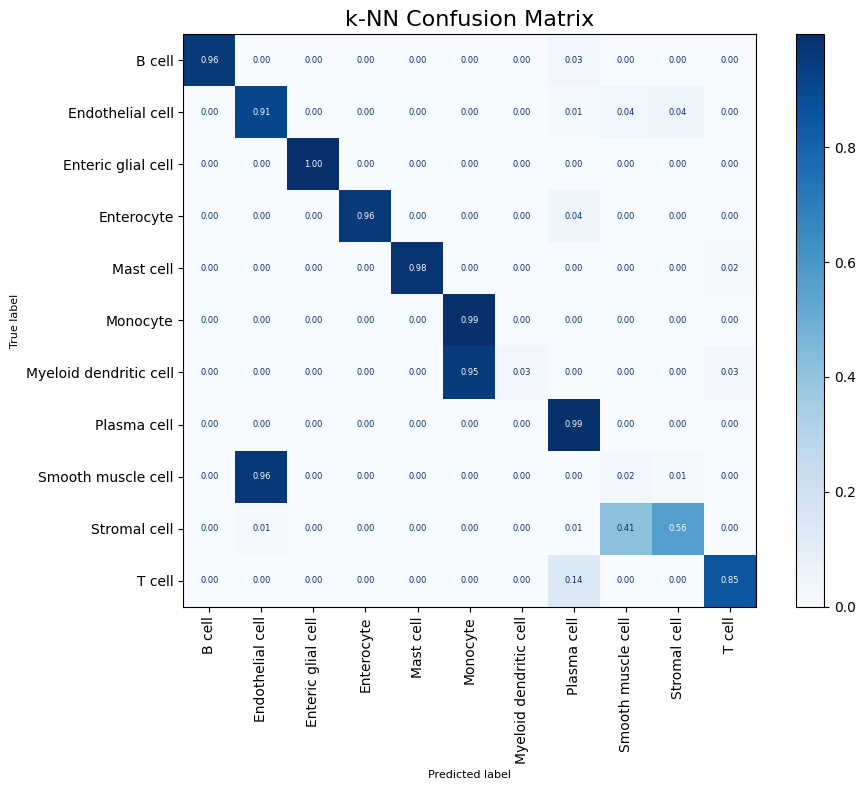

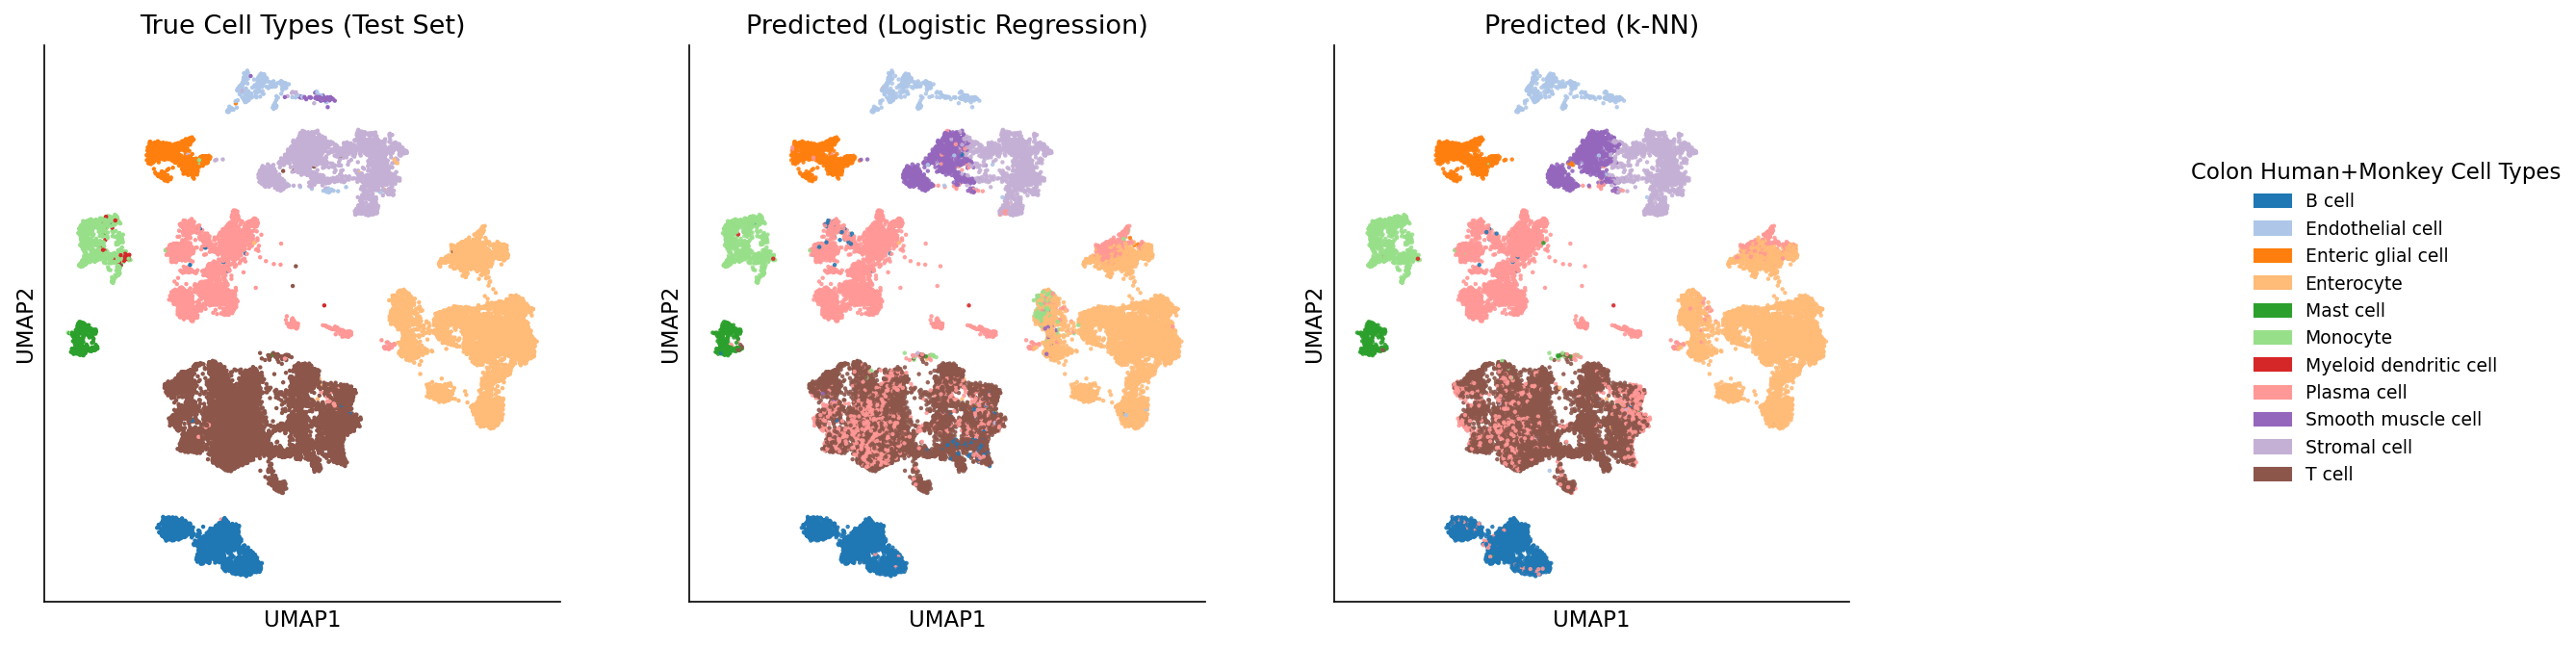

In [ ]:

from sklearn.metrics import ConfusionMatrixDisplay

train_data3 = adata[adata.obs["species"] == "monkey"]
test_data3  = adata[adata.obs["species"] != "monkey"]

X_train3 = train_data3.obsm["X_scVI"]
X_test3  = test_data3.obsm["X_scVI"]

y_train3 = train_data3.obs["cell_type"]
y_test3  = test_data3.obs["cell_type"]


# logistic regression
clf3 = LogisticRegression(max_iter=300, solver='lbfgs')

clf3.fit(X_train3, y_train3)
y_pred_lr3 = clf3.predict(X_test3)

# KNN
knn3 = KNeighborsClassifier(
    n_neighbors=15,
    weights="distance",
    metric="cosine"
)

knn3.fit(X_train3, y_train3)
y_pred_knn3 = knn3.predict(X_test3)

def plot_cm(y_true, y_pred, title):
    # Reset to default style to ensure consistency
    plt.rcdefaults()
    plt.rcParams.update({
        'figure.facecolor': 'white',
        'axes.facecolor': 'white',
        'font.family': 'sans-serif',
        'font.size': 10,
    })

    labels = np.unique(y_true)
    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize="true")

    fig, ax = plt.subplots(figsize=(10, 8), dpi=100)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(
        ax=ax,
        cmap="Blues",
        xticks_rotation=90,
        values_format=".2f",
        colorbar=True
    )
    ax.grid(False)

    for text in ax.texts:
        text.set_fontsize(6)

    plt.title(title, fontsize=16)
    plt.xlabel("Predicted label", fontsize=8)
    plt.ylabel("True label", fontsize=8)

    plt.tight_layout()
    plt.show()

print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test3, y_pred_lr3))
print(classification_report(y_test3, y_pred_lr3))
plot_cm(y_test3, y_pred_lr3, "Logistic Regression Confusion Matrix")


print("\n=== k-NN ===")
print("Accuracy:", accuracy_score(y_test3, y_pred_knn3))
print(classification_report(y_test3, y_pred_knn3))
plot_cm(y_test3, y_pred_knn3, "k-NN Confusion Matrix")

# Attach predictions to test dataset
test_data3.obs["y_pred_lr3"] = y_pred_lr3
test_data3.obs["y_pred_knn3"] = y_pred_knn3

# Fill missing values
test_data3.obs["y_pred_lr3"] = test_data3.obs["y_pred_lr3"].astype(str).fillna("Unassigned")
test_data3.obs["y_pred_knn3"] = test_data3.obs["y_pred_knn3"].astype(str).fillna("Unassigned")

# Convert to categorical
test_data3.obs["cell_type"] = test_data3.obs["cell_type"].astype("category") # Changed from celltype to cell_type
test_data3.obs["y_pred_lr3"] = test_data3.obs["y_pred_lr3"].astype("category")
test_data3.obs["y_pred_knn3"] = test_data3.obs["y_pred_knn3"].astype("category")

# Unified label set
all_labels3 = sorted(
    set(test_data3.obs["cell_type"].cat.categories)
    | set(test_data3.obs["y_pred_lr3"].cat.categories)
    | set(test_data3.obs["y_pred_knn3"].cat.categories)
)

# Force same category order
test_data3.obs["cell_type"] = test_data3.obs["cell_type"].cat.set_categories(all_labels3)
test_data3.obs["y_pred_lr3"] = test_data3.obs["y_pred_lr3"].cat.set_categories(all_labels3)
test_data3.obs["y_pred_knn3"] = test_data3.obs["y_pred_knn3"].cat.set_categories(all_labels3)

# Color map
palette = sc.pl.palettes.vega_20
color_map = {label: palette[i % len(palette)] for i, label in enumerate(all_labels3)}
color_map["Unassigned"] = "lightgray"

# Plot
fig, axes = plt.subplots(1, 3, figsize=(20, 5), dpi=150)

common_kwargs = dict(
    show=False,
    size=18,
    frameon=True,
    palette=color_map
)

# True labels
sc.pl.umap(test_data3, color="cell_type", ax=axes[0], **common_kwargs)
axes[0].set_title("True Cell Types (Test Set)", fontsize=13)

# Logistic Regression predictions
sc.pl.umap(test_data3, color="y_pred_lr3", ax=axes[1], alpha=0.9, **common_kwargs)
axes[1].set_title("Predicted (Logistic Regression)", fontsize=13)

# KNN predictions
sc.pl.umap(test_data3, color="y_pred_knn3", ax=axes[2], alpha=0.9, **common_kwargs)
axes[2].set_title("Predicted (k-NN)", fontsize=13)

# Remove auto legends
for ax in axes:
    # Remove auto legend
    if ax.legend_:
        ax.legend_.remove()

    # Force white background
    ax.set_facecolor("white")

    # Axis labels
    ax.set_xlabel("UMAP1", fontsize=11)
    ax.set_ylabel("UMAP2", fontsize=11)

    # Make axis lines visible
    ax.spines[['left', 'bottom']].set_visible(True)

    # Remove top/right box lines (clean style)
    ax.spines[['top', 'right']].set_visible(False)

    # Make axes black
    ax.spines[['left', 'bottom']].set_color("black")

    # Ticks
    ax.tick_params(
        axis='both',
        which='major',
        labelsize=9,
        colors='black'
    )
# Single clean legend
from matplotlib.patches import Patch
handles = [Patch(color=color_map[label], label=label) for label in all_labels]
fig.legend(
    handles=handles,
    title="Colon Human+Monkey Cell Types",
    loc="center right",
    frameon=False,
    fontsize=9,
    title_fontsize=11,
    ncol=1
)
plt.subplots_adjust(right=0.75, wspace=0.25)
# plt.tight_layout()
plt.show()